# 01 — Dataset Exploration

**Source:** `all_dataset_exploration.ipynb`

This notebook loads all four PROMs datasets, explains the scoring methodology, and compares hip vs knee outcomes to justify focusing on the `df_knee_provider` dataset.

In [ ]:
import pandas as pd
import numpy as np

df_hip_ccg = pd.read_parquet("../data/interim/hip-ccg.parquet")
df_knee_ccg = pd.read_parquet("../data/interim/knee-ccg.parquet")
df_hip_provider = pd.read_parquet("../data/interim/hip-provider.parquet")
df_knee_provider = pd.read_parquet("../data/interim/knee-provider.parquet")

# **Important things to keep in mind based on the description provided in references, proms_guide_V12.pdf"**

## Overview

For each patient, the PROMs dataset includes the following:
- Patient-identifiable information, which is used for linkage purposes and not made
available for wider analysis.
- A condition-specific measure of self-reported health status.
- Generic measures of self-reported health status.
- Additional questions about the patient’s own health, including whether they have preexisting conditions such as arthritis or diabetes.

Before a patient undergoes one of the four PROMs procedures, the provider should offer the
patient a PROMs questionnaire for completion. The guidance states that this should happen
in the interval between the patient being passed fit for surgery and the treatment taking
place. However, there is local discretion as to when precisely it is administered before the
procedure. Completion of the pre-operative PROMs questionnaire is voluntary for the patient
and their consent to participate must be granted for the data to be processed and used. 

## Scoring methodologies

The PROMs programme utilises a number of tested and well-established methodologies to
enable patients to rate their health status.
All patients, irrespective of their condition, are asked to complete a common set of questions
about their health status. This includes sections about the patient’s circumstances, preexisting conditions and the EQ-5DTM health questionnaire consisting of a five-dimensional
descriptive system and a visual analogue scale (EQ-VAS) developed by the EuroQol Group.
Post-operative questionnaires also contain additional questions about the surgery, such as
how the patient perceives the results of the operation and whether there were any postoperative complications, such as bleeding or wound problems.
Patients undergoing varicose vein treatment or hip and knee replacement surgery are also
asked to complete a condition-specific section.

### *EQ-5DTM*

EQ-5DTM is a standardised measure of health status developed by the EuroQol Group in
order to provide a simple, generic measure of health for clinical and economic appraisal.
Applicable to a wide range of health conditions and treatments, it provides a simple
descriptive profile and a single index value for health status that can be used in the clinical
and economic evaluation of healthcare as well as in population health surveys.
EQ-5DTM consists of two distinct sections, the EQ-5DTM descriptive system and the EQ-5DTM
visual analogue scale (EQ-VAS).
The EQ-5DTM descriptive system comprises the following five dimensions:
- Mobility
- Self-care e.g. washing and dressing
- Usual activities e.g. work, study, housework, family or leisure activities
- Pain / discomfort
- Anxiety / depression.

Each dimension has three levels: no problems, some problems, severe problems. The
respondent is asked to indicate his / her health state by ticking (or placing a cross) in the box
against the most appropriate statement in each of the five dimensions. This decision results
in a one-digit number expressing the level selected for that dimension. The digits for five
dimensions can be combined in a five-digit number string describing the respondent’s health
state, also referred to as the EQ-5DTM
’health profile’.
EQ-5DTM health states are converted into a single summary index by applying a formula that
essentially attaches values (also called ‘social preference weights’) to each of the levels in
each dimension. The index can be calculated by deducting the appropriate weights from
one, the value for full health (i.e. state 11111).
EQ-VAS consists of a simple scale, from 0 to 100, presented in a simple linear format.
Respondents are asked to rate their health state by marking the scale at the relevant point,
with zero being the worst and one hundred being the best state. See Annex 2 for more
information on the EQ-5DTM scoring system.

### *OHS and OKS*

The Oxford hip and knee scores are joint-specific outcome measure tools designed to
assess symptoms and function in patients undergoing joint replacement surgery.
The scores comprise of twelve multiple choice questions relating to the patient’s experience
of pain, ease of joint movement and ease of undertaking normal domestic activities such as
walking or climbing stairs.
Each of the 12 questions on the Oxford Hip Score and Oxford Knee Score are scored in the
same way with the score decreasing as the reported symptoms increase, i.e. become worse.
All questions are laid out similarly with response categories denoting least (or no) symptoms
scoring four and those representing greatest severity scoring zero.
The individual scores are then added together to provide a single score with 0 indicating the
worst possible and 48 indicating the highest possible score.

## Potential issues with the data

HES episodes that do not link to PROMs (unlinked episodes):
- Completion of PROMs is voluntary: patients are not obliged to take part in the PROMs
programme at either Q1 or Q2 stage.
- Lag or ‘lead in’ time before the operation: in many cases providers are administering their
Q1 questionnaire at a pre-assessment clinic up to several weeks before surgery is
scheduled. This means that a high proportion of patients who had *episodes* early in the
year would not have been invited to take part. Some patients with episodes in April would
not have completed Q1 questionnaires and many patients who had completed Q1s in
April would not have had their operation until several weeks or even months later. This
will have the effect of underestimating actual linkage performance.
- Provider mapping issues: there are instances where the Q1 may be administered to a
patient at one hospital and the operation performed at another. This may be due to
provider subcontracting arrangements, patient choice or shared pathways. The matching
algorithm can take many of these provider-to-provider relationships into account where
they are known but there will always be relationships between providers that are not
recognised.

### *Missing Values*

In instances where a patient may have either declined to answer or accidentally missed a
question, a default value is inserted to indicate a null value. For the majority of the multiple
choice questions, NULL values are replaced with a 9. For the EQ-5DTM VAS, 999 is used
because in that case 9 is a valid response.

The second exception is for the Oxford orthopaedic scores, for which the PROMs
programme adopts the permitted option to impute of missing values as the average of
present responses provided that no more than two responses are missing. Where more than
two responses are missing, the overall score is not calculated.


### **General data inspection of all files**

In [2]:
# List of dataframe variable names
df_names = ["df_hip_ccg", "df_knee_ccg", "df_hip_provider", "df_knee_provider"]

for df_name in df_names:
    print(f"\n--- {df_name} ---")
    df = globals().get(df_name)
    if df is not None:
        print("Columns:", df.columns.tolist())
        print("Missing values per column:\n", df.isnull().sum())
        print("Describe:\n", df.describe(include='all'))
    else:
        print(f"{df_name} not loaded.")


--- df_hip_ccg ---
Columns: ['provider_code', 'procedure', 'revision_flag', 'year', 'age_band', 'gender', 't0_assisted', 't0_assisted_by', 't0_symptom_period', 't0_previous_surgery', 't0_living_arrangements', 't0_disability', 'heart_disease', 'high_bp', 'stroke', 'circulation', 'lung_disease', 'diabetes', 'kidney_disease', 'nervous_system', 'liver_disease', 'cancer', 'depression', 'arthritis', 't0_mobility', 't0_self_care', 't0_activity', 't0_discomfort', 't0_anxiety', 't0_eq5d_index_profile', 't0_eq5d_index', 't1_assisted', 't1_assisted_by', 't1_living_arrangements', 't1_disability', 't1_mobility', 't1_self_care', 't1_activity', 't1_discomfort', 't1_anxiety', 't1_satisfaction', 't1_sucess', 't1_allergy', 't1_bleeding', 't1_wound', 't1_urine', 't1_further_surgery', 't1_readmitted', 't1_eq5d_index_profile', 't1_eq5d_index', 'ohs_eq5d_index_t1_predicted', 't0_eq_vas', 't1_eq_vas', 'ohs_eq_vas_t1_predicted', 'ohs_t0_pain', 'ohs_t0_sudden_pain', 'ohs_t0_night_pain', 'ohs_t0_washing', 'ohs

In [3]:
# Missing values for t0 and t1 scores, specifically for t1_eq5d_index, t1_eq5d_vas, ohs_score for df_hip_provider

df = globals().get("df_knee_provider")
if df is not None:
    columns_of_interest = [
        "t0_eq_vas", "oks_t0_score",
        "t1_eq_vas", "oks_t1_score"
    ]
    print("\nMissing values for columns of interest:")
    for col in columns_of_interest:
        if col in df.columns:
            missing = df[col].isnull().sum()
            total = len(df)
            print(f"{col}: {missing} missing ({missing/total:.2%})")
        else:
            print(f"{col}: column not found in df_hip_provider")

    print("\nNumber of patients with answers at t0 and t1 of the OS:")
    t0_answered = df.dropna(subset=["oks_t0_score"]).shape[0]
    t1_answered = df.dropna(subset=["oks_t1_score"]).shape[0]
    print(f"Answered all t0 scores: {t0_answered} / {len(df)}")
    print(f"Answered all t1 scores: {t1_answered} / {len(df)}")
    print("\nNumber of patients with answers at t0 and t1 of the EQ5D - VAS and replace 999 with na:")
    t0_answered = df.replace(999, np.nan).dropna(subset=["t0_eq_vas"]).shape[0]
    t1_answered = df.replace(999, np.nan).dropna(subset=["t1_eq_vas"]).shape[0]
    print(f"Answered all t0 scores: {t0_answered} / {len(df)}")
    print(f"Answered all t1 scores: {t1_answered} / {len(df)}")
    print("\nNumber of patients with answers at t0 and t1 of the t0 and t1 of the EQ5D - Index:")
    t0_answered = df.dropna(subset=["t0_eq5d_index"]).shape[0]
    t1_answered = df.dropna(subset=["t1_eq5d_index"]).shape[0]
    print(f"Answered all t0 scores: {t0_answered} / {len(df)}")
    print(f"Answered all t1 scores: {t1_answered} / {len(df)}")
else:
    print("df_hip_provider not loaded.")


Missing values for columns of interest:
t0_eq_vas: 0 missing (0.00%)
oks_t0_score: 1669 missing (1.20%)
t1_eq_vas: 0 missing (0.00%)
oks_t1_score: 2579 missing (1.85%)

Number of patients with answers at t0 and t1 of the OS:
Answered all t0 scores: 137567 / 139236
Answered all t1 scores: 136657 / 139236

Number of patients with answers at t0 and t1 of the EQ5D - VAS and replace 999 with na:
Answered all t0 scores: 126275 / 139236
Answered all t1 scores: 132690 / 139236

Number of patients with answers at t0 and t1 of the t0 and t1 of the EQ5D - Index:
Answered all t0 scores: 131736 / 139236
Answered all t1 scores: 132962 / 139236


In [4]:
import numpy as np
import pandas as pd

def analyze_missing_scores(df, df_name):
    """Analyze missing values for PROMs scores in a dataset with formatted tables."""
    
    print(f"\n{'='*80}")
    print(f"ANALYSIS FOR: {df_name}")
    print(f"{'='*80}")
    
    if df is None:
        print(f"{df_name} not loaded.")
        return
    
    print(f"Total records: {len(df):,}\n")
    
    # Define columns to check
    columns_of_interest = [
        "t0_eq_vas", "t1_eq_vas",
        "t0_eq5d_index", "t1_eq5d_index",
        "oks_t0_score", "oks_t1_score",
        "oks_t0_score", "oks_t1_score"
    ]
    
    existing_cols = [col for col in columns_of_interest if col in df.columns]
    
    if not existing_cols:
        print("None of the standard PROMs columns found in this dataset.")
        return
    
    # Create missing values table
    print("MISSING VALUES SUMMARY:")
    missing_data = []
    for col in existing_cols:
        missing = df[col].isnull().sum()
        present = len(df) - missing
        missing_pct = (missing / len(df)) * 100
        present_pct = 100 - missing_pct
        missing_data.append({
            'Column': col,
            'Present': f"{present:,}",
            'Missing': f"{missing:,}",
            'Missing %': f"{missing_pct:.2f}%",
            'Present %': f"{present_pct:.2f}%"
        })
    
    missing_df = pd.DataFrame(missing_data)
    print(missing_df.to_string(index=False))
    print()
    
    # Helper function for paired analysis
    def create_paired_table(t0_col, t1_col, score_name, replace_999=False):
        if t0_col not in df.columns or t1_col not in df.columns:
            return
        
        print(f"\n{score_name} COMPLETENESS:")
        
        df_temp = df.replace(999, np.nan) if replace_999 else df
        
        total = len(df)
        t0_answered = df_temp[t0_col].notna().sum()
        t1_answered = df_temp[t1_col].notna().sum()
        both_answered = df_temp[[t0_col, t1_col]].notna().all(axis=1).sum()
        t0_only = df_temp[t0_col].notna().sum() - both_answered
        t1_only = df_temp[t1_col].notna().sum() - both_answered
        neither = total - t0_answered - t1_only
        
        completeness_data = [
            {
                'Category': 'Both t0 AND t1',
                'Count': f"{both_answered:,}",
                'Percentage': f"{(both_answered/total)*100:.2f}%"
            },
            {
                'Category': 't0 only',
                'Count': f"{t0_only:,}",
                'Percentage': f"{(t0_only/total)*100:.2f}%"
            },
            {
                'Category': 't1 only',
                'Count': f"{t1_only:,}",
                'Percentage': f"{(t1_only/total)*100:.2f}%"
            },
            {
                'Category': 'Neither t0 nor t1',
                'Count': f"{neither:,}",
                'Percentage': f"{(neither/total)*100:.2f}%"
            },
            {
                'Category': '─' * 20,
                'Count': '─' * 10,
                'Percentage': '─' * 10
            },
            {
                'Category': 'Total with t0',
                'Count': f"{t0_answered:,}",
                'Percentage': f"{(t0_answered/total)*100:.2f}%"
            },
            {
                'Category': 'Total with t1',
                'Count': f"{t1_answered:,}",
                'Percentage': f"{(t1_answered/total)*100:.2f}%"
            }
        ]
        
        completeness_df = pd.DataFrame(completeness_data)
        print(completeness_df.to_string(index=False))
    
    # Analyze each score type
    create_paired_table("oks_t0_score", "oks_t1_score", "OXFORD HIP SCORE (OHS)")
    create_paired_table("oks_t0_score", "oks_t1_score", "OXFORD KNEE SCORE (OKS)")
    create_paired_table("t0_eq_vas", "t1_eq_vas", "EQ5D VAS (999 treated as missing)", replace_999=True)
    create_paired_table("t0_eq5d_index", "t1_eq5d_index", "EQ5D INDEX")


# List of all datasets to analyze
datasets_to_check = [
    "df_hip_provider",
    "df_hip_ccg",
    "df_knee_provider",
    "df_knee_ccg"
]

# Run analysis for each dataset
for dataset_name in datasets_to_check:
    df = globals().get(dataset_name)
    analyze_missing_scores(df, dataset_name)

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)


ANALYSIS FOR: df_hip_provider
Total records: 124,844

MISSING VALUES SUMMARY:
       Column Present Missing Missing % Present %
    t0_eq_vas 124,844       0     0.00%   100.00%
    t1_eq_vas 124,844       0     0.00%   100.00%
t0_eq5d_index 117,824   7,020     5.62%    94.38%
t1_eq5d_index 119,467   5,377     4.31%    95.69%


EQ5D VAS (999 treated as missing) COMPLETENESS:
            Category      Count Percentage
      Both t0 AND t1    108,551     86.95%
             t0 only      5,024      4.02%
             t1 only     10,213      8.18%
   Neither t0 nor t1      1,056      0.85%
──────────────────── ────────── ──────────
       Total with t0    113,575     90.97%
       Total with t1    118,764     95.13%

EQ5D INDEX COMPLETENESS:
            Category      Count Percentage
      Both t0 AND t1    112,971     90.49%
             t0 only      4,853      3.89%
             t1 only      6,496      5.20%
   Neither t0 nor t1        524      0.42%
──────────────────── ────────── ────

In [8]:
import pandas as pd

def analyze_eq5d_profiles(df, df_name):
    """Analyze EQ5D profiles containing '9' and their relationship to NaN indices."""
    
    print(f"\n{'='*80}")
    print(f"EQ5D PROFILE ANALYSIS FOR: {df_name}")
    print(f"{'='*80}")
    
    if df is None:
        print(f"{df_name} not loaded.")
        return
    
    # Check if required columns exist
    profile_cols = [col for col in df.columns if 'eq5d_index_profile' in col]
    index_cols = [col for col in df.columns if col.endswith('eq5d_index') and 'profile' not in col]
    
    if not profile_cols or not index_cols:
        print(f"No EQ5D profile/index columns found in {df_name}")
        return
    
    # Analyze each t0/t1 pair
    for time_point in ['t0', 't1']:
        profile_col = f'{time_point}_eq5d_index_profile'
        index_col = f'{time_point}_eq5d_index'
        
        if profile_col not in df.columns or index_col not in df.columns:
            continue
        
        print(f"\n{'─'*80}")
        print(f"TIME POINT: {time_point.upper()}")
        print(f"{'─'*80}")
        
        # Create working dataframe
        df_check = df[[profile_col, index_col]].copy()
        df_check['profile_str'] = df_check[profile_col].astype(str)
        df_check['contains_9'] = df_check['profile_str'].str.contains('9', na=False)
        
        # Overall summary
        total_rows = len(df_check)
        with_9 = df_check['contains_9'].sum()
        without_9 = (~df_check['contains_9']).sum()
        
        print(f"\nOVERALL SUMMARY:")
        print(f"Total rows: {total_rows:,}")
        print(f"Profiles containing '9': {with_9:,} ({(with_9/total_rows)*100:.2f}%)")
        print(f"Profiles NOT containing '9': {without_9:,} ({(without_9/total_rows)*100:.2f}%)")
        
        # Profiles WITH '9'
        profiles_with_9 = df_check[df_check['contains_9']]
        with_9_nan = profiles_with_9[index_col].isna().sum()
        with_9_not_nan = profiles_with_9[index_col].notna().sum()
        
        # Profiles WITHOUT '9'
        profiles_without_9 = df_check[~df_check['contains_9']]
        without_9_nan = profiles_without_9[index_col].isna().sum()
        without_9_not_nan = profiles_without_9[index_col].notna().sum()
        
        # Create summary table
        summary_data = [
            {
                'Profile Type': "Contains '9'",
                'Total': f"{len(profiles_with_9):,}",
                'Index is NaN': f"{with_9_nan:,}",
                'Index is NOT NaN': f"{with_9_not_nan:,}",
                'NaN %': f"{(with_9_nan/len(profiles_with_9)*100) if len(profiles_with_9) > 0 else 0:.2f}%"
            },
            {
                'Profile Type': "Does NOT contain '9'",
                'Total': f"{len(profiles_without_9):,}",
                'Index is NaN': f"{without_9_nan:,}",
                'Index is NOT NaN': f"{without_9_not_nan:,}",
                'NaN %': f"{(without_9_nan/len(profiles_without_9)*100) if len(profiles_without_9) > 0 else 0:.2f}%"
            }
        ]
        
        summary_df = pd.DataFrame(summary_data)
        print("\nDETAILED BREAKDOWN:")
        print(summary_df.to_string(index=False))
        
        # Check for unusual cases
        print("\nVALIDATION CHECKS:")
        
        # Case 1: Profiles with '9' that have NON-NaN index (should be 0)
        non_nan_with_9 = df_check[df_check['contains_9'] & df_check[index_col].notna()]
        if len(non_nan_with_9) > 0:
            print(f"⚠️  UNUSUAL: {len(non_nan_with_9)} profiles with '9' have NON-NaN index")
            print("\nExamples:")
            print(non_nan_with_9[[profile_col, index_col]].head(10).to_string(index=True))
        else:
            print(f"✓ CONFIRMED: ALL {with_9:,} profiles with '9' result in NaN index")
        
        # Case 2: Profiles without '9' that have NaN (might be other data issues)
        nan_without_9 = df_check[(~df_check['contains_9']) & df_check[index_col].isna()]
        if len(nan_without_9) > 0:
            print(f"\n⚠️  NOTE: {len(nan_without_9):,} profiles WITHOUT '9' still have NaN index")
            print("(This could be due to other data quality issues)")
            print("\nExamples:")
            print(nan_without_9[[profile_col, index_col]].head(10).to_string(index=True))
        else:
            print(f"✓ All profiles without '9' have valid index values")
        
        # Show some examples of profiles with '9'
        if len(profiles_with_9) > 0:
            print(f"\nEXAMPLES OF PROFILES WITH '9':")
            examples = profiles_with_9[[profile_col, index_col]].head(10)
            print(examples.to_string(index=True))


# List of all datasets to analyze
datasets_to_check = [
    "df_hip_provider",
    "df_hip_ccg",
    "df_knee_provider",
    "df_knee_ccg"
]

# Run analysis for each dataset
for dataset_name in datasets_to_check:
    df = globals().get(dataset_name)
    analyze_eq5d_profiles(df, dataset_name)

print("\n" + "="*80)
print("EQ5D PROFILE ANALYSIS COMPLETE")
print("="*80)


EQ5D PROFILE ANALYSIS FOR: df_hip_provider

────────────────────────────────────────────────────────────────────────────────
TIME POINT: T0
────────────────────────────────────────────────────────────────────────────────

OVERALL SUMMARY:
Total rows: 124,844
Profiles containing '9': 7,020 (5.62%)
Profiles NOT containing '9': 117,824 (94.38%)

DETAILED BREAKDOWN:
        Profile Type   Total Index is NaN Index is NOT NaN   NaN %
        Contains '9'   7,020        7,020                0 100.00%
Does NOT contain '9' 117,824            0          117,824   0.00%

VALIDATION CHECKS:
✓ CONFIRMED: ALL 7,020 profiles with '9' result in NaN index
✓ All profiles without '9' have valid index values

EXAMPLES OF PROFILES WITH '9':
     t0_eq5d_index_profile  t0_eq5d_index
38                   92233            NaN
39                   99999            NaN
54                   29122            NaN
82                   99999            NaN
100                  99999            NaN
101              

In [9]:
import pandas as pd
import numpy as np

def simple_t0_t1_analysis(df, df_name):
    """Simple analysis: who filled t0 but not t1, and vice versa."""
    
    if df is None:
        print(f"{df_name} not loaded.\n")
        return None
    
    total = len(df)
    
    # Define t0/t1 pairs to check
    variable_pairs = [
        ('oks_t0_score', 'oks_t1_score', 'Oxford Hip Score'),
        ('oks_t0_score', 'oks_t1_score', 'Oxford Knee Score'),
        ('t0_eq_vas', 't1_eq_vas', 'EQ5D VAS'),
        ('t0_eq5d_index', 't1_eq5d_index', 'EQ5D Index')
    ]
    
    results = []
    
    for t0_col, t1_col, var_name in variable_pairs:
        # Skip if columns don't exist
        if t0_col not in df.columns or t1_col not in df.columns:
            continue
        
        # For VAS, replace 999 with NaN
        if 'vas' in t0_col.lower():
            df_temp = df[[t0_col, t1_col]].replace(999, np.nan)
        else:
            df_temp = df[[t0_col, t1_col]]
        
        # Calculate all four combinations
        both_filled = (df_temp[t0_col].notna() & df_temp[t1_col].notna()).sum()
        t0_only = (df_temp[t0_col].notna() & df_temp[t1_col].isna()).sum()
        t1_only = (df_temp[t0_col].isna() & df_temp[t1_col].notna()).sum()
        neither = (df_temp[t0_col].isna() & df_temp[t1_col].isna()).sum()
        
        results.append({
            'Variable': var_name,
            'Both_t0_t1_count': both_filled,
            'Both_t0_t1_pct': round(both_filled/total*100, 1),
            't0_only_count': t0_only,
            't0_only_pct': round(t0_only/total*100, 1),
            't1_only_count': t1_only,
            't1_only_pct': round(t1_only/total*100, 1),
            'Neither_count': neither,
            'Neither_pct': round(neither/total*100, 1)
        })
    
    if results:
        results_df = pd.DataFrame(results)
        return results_df, total
    else:
        return None, total


# Set display options for better dataframe viewing
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Run for all datasets
datasets = ["df_hip_provider", "df_hip_ccg", "df_knee_provider", "df_knee_ccg"]

all_results = {}

for dataset_name in datasets:
    print(f"\n{'='*80}")
    print(f"{dataset_name}")
    print(f"{'='*80}")
    
    df = globals().get(dataset_name)
    result_df, total = simple_t0_t1_analysis(df, dataset_name)
    
    if result_df is not None:
        print(f"Total patients: {total:,}\n")
        display(result_df)  # Use display() for Jupyter notebooks
        # OR use print(result_df) if not in Jupyter
        all_results[dataset_name] = result_df
    else:
        print("No t0/t1 variable pairs found in this dataset.")

print(f"\n{'='*80}")
print("ANALYSIS COMPLETE")
print(f"{'='*80}")


df_hip_provider
Total patients: 124,844



,Variable,Both_t0_t1_count,Both_t0_t1_pct,t0_only_count,t0_only_pct,t1_only_count,t1_only_pct,Neither_count,Neither_pct
0,EQ5D VAS,108551,86.9,5024,4.0,10213,8.2,1056,0.8
1,EQ5D Index,112971,90.5,4853,3.9,6496,5.2,524,0.4



df_hip_ccg
Total patients: 122,294



,Variable,Both_t0_t1_count,Both_t0_t1_pct,t0_only_count,t0_only_pct,t1_only_count,t1_only_pct,Neither_count,Neither_pct
0,EQ5D VAS,106361,87.0,4899,4.0,9996,8.2,1038,0.8
1,EQ5D Index,110668,90.5,4744,3.9,6369,5.2,513,0.4



df_knee_provider
Total patients: 139,236



,Variable,Both_t0_t1_count,Both_t0_t1_pct,t0_only_count,t0_only_pct,t1_only_count,t1_only_pct,Neither_count,Neither_pct
0,Oxford Hip Score,135051,97.0,2516,1.8,1606,1.2,63,0.0
1,Oxford Knee Score,135051,97.0,2516,1.8,1606,1.2,63,0.0
2,EQ5D VAS,120904,86.8,5371,3.9,11786,8.5,1175,0.8
3,EQ5D Index,126038,90.5,5698,4.1,6924,5.0,576,0.4



df_knee_ccg
Total patients: 136,390



,Variable,Both_t0_t1_count,Both_t0_t1_pct,t0_only_count,t0_only_pct,t1_only_count,t1_only_pct,Neither_count,Neither_pct
0,Oxford Hip Score,132269,97.0,2478,1.8,1583,1.2,60,0.0
1,Oxford Knee Score,132269,97.0,2478,1.8,1583,1.2,60,0.0
2,EQ5D VAS,118411,86.8,5248,3.8,11584,8.5,1147,0.8
3,EQ5D Index,123467,90.5,5563,4.1,6794,5.0,566,0.4



ANALYSIS COMPLETE


In [ ]:
# Calculate the average improvement (delta) in oks_t1_score - oks_t0_score for df_hip_provider and oks_t1_score - oks_t0_score for df_knee_provider where both scores are filled.

df_hip = globals().get("df_hip_provider")
df_knee = globals().get("df_knee_provider")
if df_hip is not None:
    # Filter for patients with both scores filled
    df_hip_filtered = df_hip.dropna(subset=['ohs_t0_score', 'ohs_t1_score']).copy()
    # Calculate delta
    df_hip_filtered['ohs_delta'] = df_hip_filtered['ohs_t1_score'] - df_hip_filtered['ohs_t0_score']
    # Calculate average improvement
    avg_improvement_hip = df_hip_filtered['ohs_delta'].mean()
    print(f"Average improvement in OHS Score (T1 - T0) for Hip Patients: {avg_improvement_hip:.2f}")

if df_knee is not None:
    # Filter for patients with both scores filled
    df_knee_filtered = df_knee.dropna(subset=['oks_t0_score', 'oks_t1_score']).copy()
    # Calculate delta
    df_knee_filtered['oks_delta'] = df_knee_filtered['oks_t1_score'] - df_knee_filtered['oks_t0_score']
    # Calculate average improvement
    avg_improvement_knee = df_knee_filtered['oks_delta'].mean()
    print(f"Average improvement in OKS Score (T1 - T0) for Knee Patients: {avg_improvement_knee:.2f}")

Average improvement in OHS Score (T1 - T0) for Hip Patients: 21.94
Average improvement in OKS Score (T1 - T0) for Knee Patients: 16.89


In [2]:
# Beautiful Altair Visualizations: Knee vs Hip Provider Comparison
# Focus on score improvements and the 7-point cutoff justification

import altair as alt
import pandas as pd
import numpy as np

# Load the data
df_knee_provider = pd.read_parquet('../data/interim/knee-provider.parquet')
df_hip_provider = pd.read_parquet('../data/interim/hip-provider.parquet')

# Prepare knee data
df_knee_filtered = df_knee_provider.dropna(subset=['oks_t0_score', 'oks_t1_score']).copy()
df_knee_filtered['delta'] = df_knee_filtered['oks_t1_score'] - df_knee_filtered['oks_t0_score']
df_knee_filtered['surgery_type'] = 'Knee'
df_knee_filtered['score_type'] = 'OKS'

# Prepare hip data  
df_hip_filtered = df_hip_provider.dropna(subset=['ohs_t0_score', 'ohs_t1_score']).copy()
df_hip_filtered['delta'] = df_hip_filtered['ohs_t1_score'] - df_hip_filtered['ohs_t0_score']
df_hip_filtered['surgery_type'] = 'Hip'
df_hip_filtered['score_type'] = 'OHS'

# Combine for comparison
df_combined = pd.concat([
    df_knee_filtered[['delta', 'surgery_type', 'score_type']],
    df_hip_filtered[['delta', 'surgery_type', 'score_type']]
], ignore_index=True)

# Print summary statistics
print("="*80)
print("SCORE IMPROVEMENT ANALYSIS: KNEE vs HIP PROCEDURES")
print("="*80)
print(f"\nKNEE (OKS) Statistics:")
print(f"  Total patients with both scores: {len(df_knee_filtered):,}")
print(f"  Mean improvement: {df_knee_filtered['delta'].mean():.2f} points")
print(f"  Median improvement: {df_knee_filtered['delta'].median():.2f} points")
print(f"  Std deviation: {df_knee_filtered['delta'].std():.2f} points")
print(f"  Patients with Δ ≥ 7: {(df_knee_filtered['delta'] >= 7).sum():,} ({(df_knee_filtered['delta'] >= 7).mean()*100:.1f}%)")

print(f"\nHIP (OHS) Statistics:")
print(f"  Total patients with both scores: {len(df_hip_filtered):,}")
print(f"  Mean improvement: {df_hip_filtered['delta'].mean():.2f} points")
print(f"  Median improvement: {df_hip_filtered['delta'].median():.2f} points")
print(f"  Std deviation: {df_hip_filtered['delta'].std():.2f} points")
print(f"  Patients with Δ ≥ 7: {(df_hip_filtered['delta'] >= 7).sum():,} ({(df_hip_filtered['delta'] >= 7).mean()*100:.1f}%)")
print("="*80)

SCORE IMPROVEMENT ANALYSIS: KNEE vs HIP PROCEDURES

KNEE (OKS) Statistics:
  Total patients with both scores: 135,051
  Mean improvement: 16.89 points
  Median improvement: 17.00 points
  Std deviation: 9.86 points
  Patients with Δ ≥ 7: 114,868 (85.1%)

HIP (OHS) Statistics:
  Total patients with both scores: 122,033
  Mean improvement: 21.94 points
  Median improvement: 23.00 points
  Std deviation: 10.20 points
  Patients with Δ ≥ 7: 112,743 (92.4%)


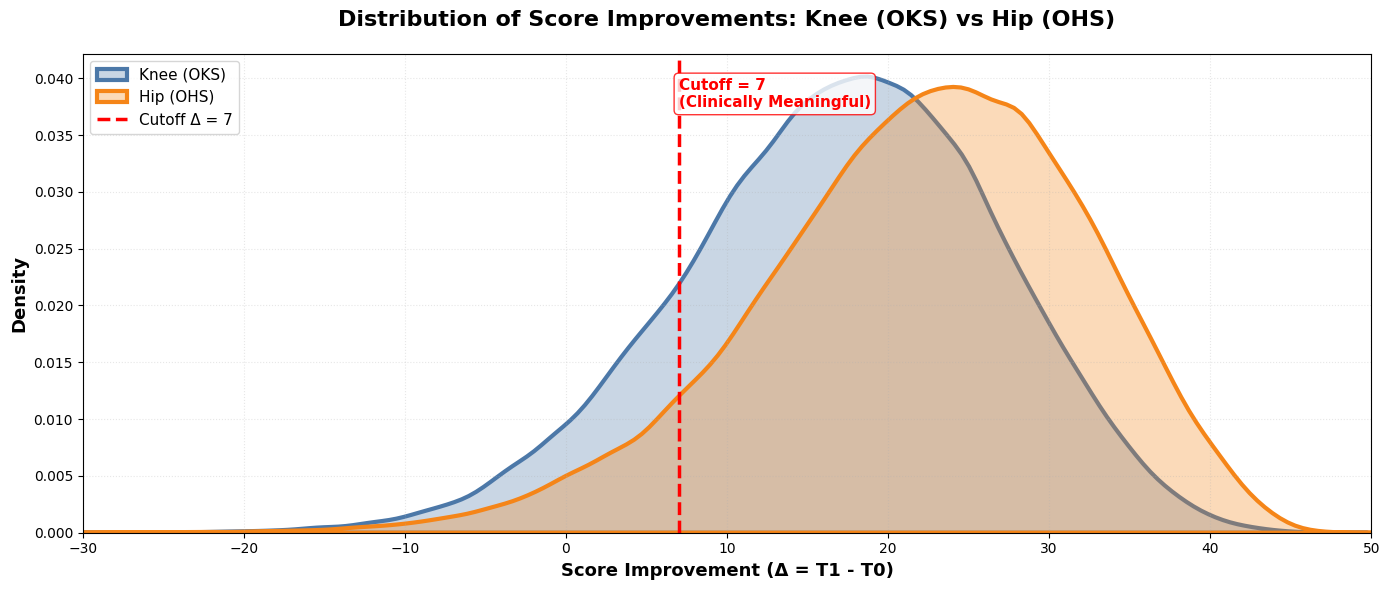


Key Insight: Both procedures show positive improvements on average,
with the majority of patients experiencing clinically meaningful gains (Δ ≥ 7).


: 

In [ ]:
# VISUALIZATION 1: Delta Distribution Comparison with Seaborn
# Beautiful smooth density curves showing improvement distributions

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(14, 6))

# Plot smooth KDE density curves only (no histograms)
sns.kdeplot(data=df_knee_filtered, x='delta', fill=True, alpha=0.3, 
            label='Knee (OKS)', color='#4C78A8', linewidth=3, ax=ax)
sns.kdeplot(data=df_hip_filtered, x='delta', fill=True, alpha=0.3, 
            label='Hip (OHS)', color='#F58518', linewidth=3, ax=ax)

# Add vertical line at cutoff = 7
ax.axvline(x=7, color='red', linestyle='--', linewidth=2.5, label='Cutoff Δ = 7')

# Annotations
ax.text(7, ax.get_ylim()[1] * 0.95, 'Cutoff = 7\n(Clinically Meaningful)', 
        color='red', fontsize=11, fontweight='bold', ha='left', va='top',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='red', alpha=0.8))

# Styling
ax.set_xlabel('Score Improvement (Δ = T1 - T0)', fontsize=13, fontweight='bold')
ax.set_ylabel('Density', fontsize=13, fontweight='bold')
ax.set_title('Distribution of Score Improvements: Knee (OKS) vs Hip (OHS)', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3, linestyle=':')
ax.set_xlim(-30, 50)

plt.tight_layout()
plt.show()

print(f"\nKey Insight: Both procedures show positive improvements on average,")
print(f"with the majority of patients experiencing clinically meaningful gains (Δ ≥ 7).")

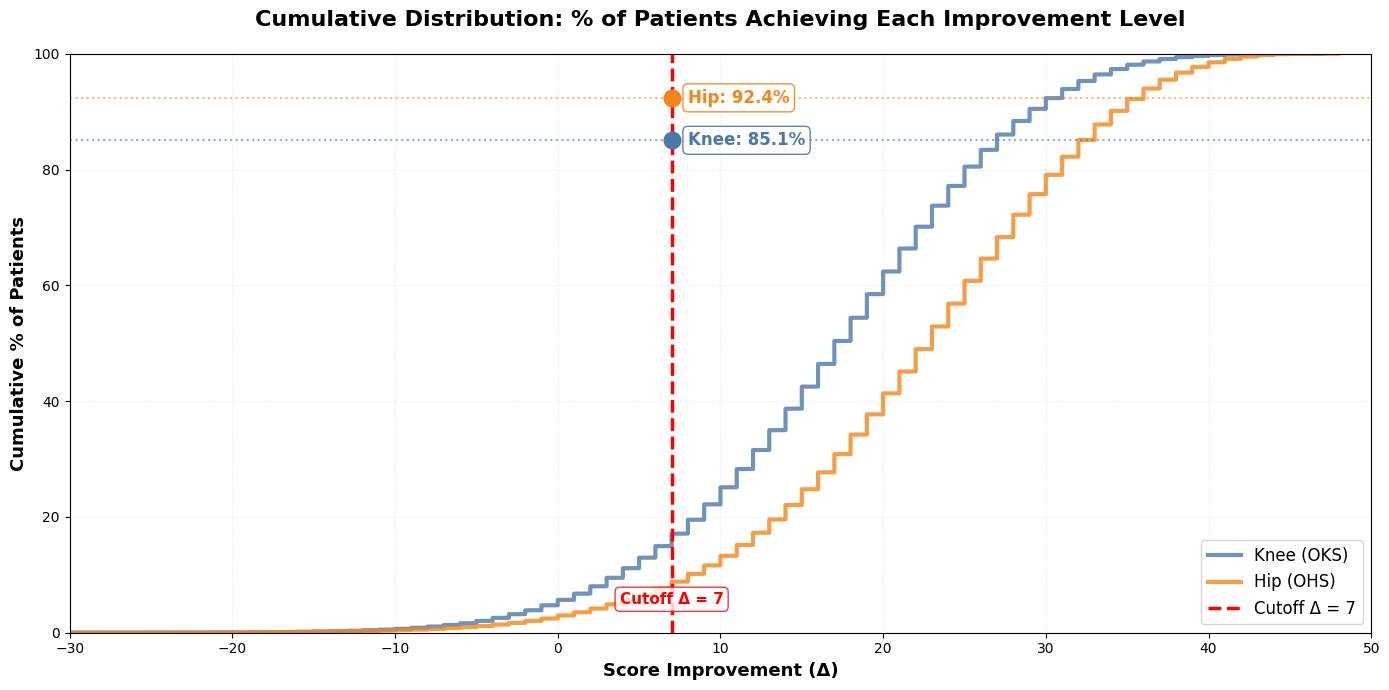


Key Insight: At the cutoff of Δ = 7:
  • 85.1% of knee patients (114,868 patients) achieved clinically meaningful improvement
  • 92.4% of hip patients (112,743 patients) achieved clinically meaningful improvement


In [5]:
# VISUALIZATION 2: Cumulative Distribution - What % of patients achieved X improvement?
# Shows clearly how many patients benefit at different cutoff levels

# Prepare cumulative data
knee_sorted = np.sort(df_knee_filtered['delta'].values)
knee_cumulative = np.arange(1, len(knee_sorted) + 1) / len(knee_sorted) * 100

hip_sorted = np.sort(df_hip_filtered['delta'].values)
hip_cumulative = np.arange(1, len(hip_sorted) + 1) / len(hip_sorted) * 100

# Create figure
fig, ax = plt.subplots(figsize=(14, 7))

# Plot cumulative distributions
ax.plot(knee_sorted, knee_cumulative, color='#4C78A8', linewidth=3, label='Knee (OKS)', alpha=0.8)
ax.plot(hip_sorted, hip_cumulative, color='#F58518', linewidth=3, label='Hip (OHS)', alpha=0.8)

# Add vertical line at cutoff = 7
ax.axvline(x=7, color='red', linestyle='--', linewidth=2.5, label='Cutoff Δ = 7')

# Calculate percentages at cutoff
knee_pct_at_7 = (df_knee_filtered['delta'] >= 7).mean() * 100
hip_pct_at_7 = (df_hip_filtered['delta'] >= 7).mean() * 100

# Add horizontal lines showing % at cutoff
ax.axhline(y=knee_pct_at_7, color='#4C78A8', linestyle=':', linewidth=1.5, alpha=0.6)
ax.axhline(y=hip_pct_at_7, color='#F58518', linestyle=':', linewidth=1.5, alpha=0.6)

# Add points and annotations at cutoff
ax.plot(7, knee_pct_at_7, 'o', color='#4C78A8', markersize=12, zorder=5)
ax.plot(7, hip_pct_at_7, 'o', color='#F58518', markersize=12, zorder=5)

ax.text(8, knee_pct_at_7, f'Knee: {knee_pct_at_7:.1f}%', 
        color='#4C78A8', fontsize=12, fontweight='bold', va='center',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='#4C78A8', alpha=0.9))

ax.text(8, hip_pct_at_7, f'Hip: {hip_pct_at_7:.1f}%', 
        color='#F58518', fontsize=12, fontweight='bold', va='center',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='#F58518', alpha=0.9))

# Annotation for cutoff
ax.text(7, 5, 'Cutoff Δ = 7', color='red', fontsize=11, fontweight='bold', 
        ha='center', rotation=0,
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='red', alpha=0.8))

# Styling
ax.set_xlabel('Score Improvement (Δ)', fontsize=13, fontweight='bold')
ax.set_ylabel('Cumulative % of Patients', fontsize=13, fontweight='bold')
ax.set_title('Cumulative Distribution: % of Patients Achieving Each Improvement Level', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_subtitle = 'Shows what percentage of patients achieved at least X points of improvement'
ax.legend(fontsize=12, loc='lower right')
ax.grid(True, alpha=0.3, linestyle=':')
ax.set_xlim(-30, 50)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print(f"\nKey Insight: At the cutoff of Δ = 7:")
print(f"  • {knee_pct_at_7:.1f}% of knee patients ({(df_knee_filtered['delta'] >= 7).sum():,} patients) achieved clinically meaningful improvement")
print(f"  • {hip_pct_at_7:.1f}% of hip patients ({(df_hip_filtered['delta'] >= 7).sum():,} patients) achieved clinically meaningful improvement")

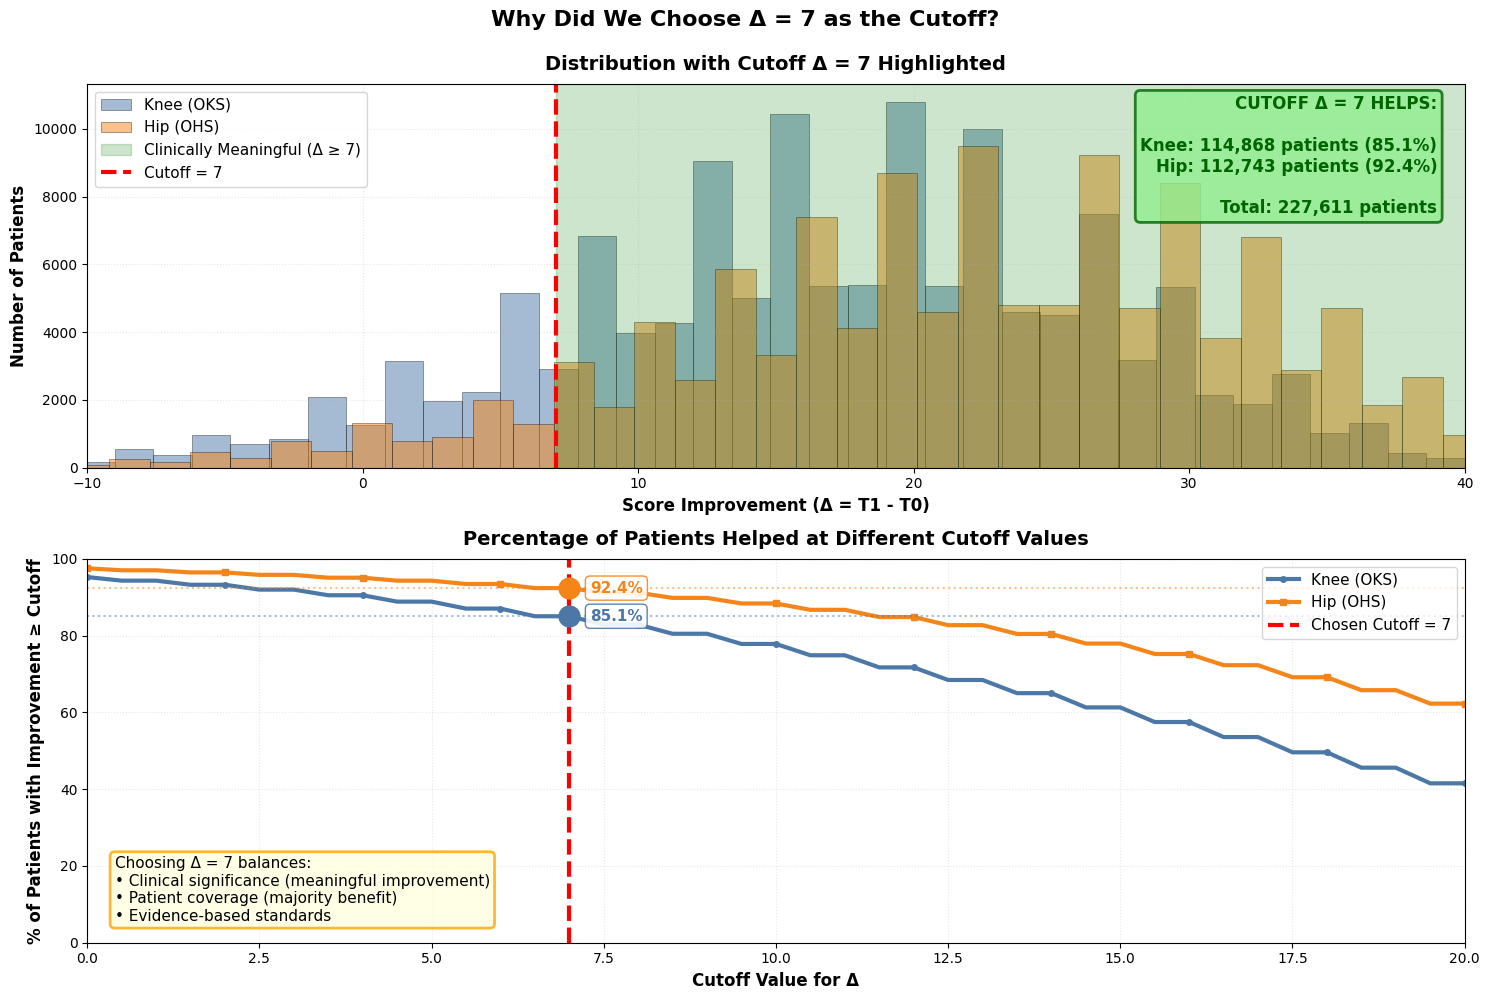


CUTOFF JUSTIFICATION SUMMARY

At Δ = 7:
  • Represents clinically meaningful improvement (evidence-based threshold)
  • 85.1% of knee patients benefit (114,868 patients)
  • 92.4% of hip patients benefit (112,743 patients)
  • Total patients helped: 227,611

This cutoff maximizes patient benefit while maintaining clinical significance.


In [7]:
# VISUALIZATION 4: Why Δ = 7? Cutoff Justification Chart
# Demonstrates the rationale for choosing 7 as the clinical cutoff

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# ===== TOP PANEL: Distribution with highlighted cutoff area =====
# Histogram for both procedures
ax1.hist(df_knee_filtered['delta'], bins=60, alpha=0.5, color='#4C78A8', 
         label='Knee (OKS)', edgecolor='black', linewidth=0.5)
ax1.hist(df_hip_filtered['delta'], bins=60, alpha=0.5, color='#F58518', 
         label='Hip (OHS)', edgecolor='black', linewidth=0.5)

# Highlight area where delta >= 7
ax1.axvspan(7, 50, alpha=0.2, color='green', label='Clinically Meaningful (Δ ≥ 7)')
ax1.axvline(x=7, color='red', linestyle='--', linewidth=3, label='Cutoff = 7')

# Calculate and display key numbers
knee_count_helped = (df_knee_filtered['delta'] >= 7).sum()
hip_count_helped = (df_hip_filtered['delta'] >= 7).sum()
knee_pct_helped = (df_knee_filtered['delta'] >= 7).mean() * 100
hip_pct_helped = (df_hip_filtered['delta'] >= 7).mean() * 100

# Add annotation box with key statistics
info_text = f"CUTOFF Δ = 7 HELPS:\n\n" \
            f"Knee: {knee_count_helped:,} patients ({knee_pct_helped:.1f}%)\n" \
            f"Hip: {hip_count_helped:,} patients ({hip_pct_helped:.1f}%)\n\n" \
            f"Total: {knee_count_helped + hip_count_helped:,} patients"

ax1.text(0.98, 0.97, info_text, transform=ax1.transAxes,
         fontsize=12, fontweight='bold', color='darkgreen',
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8, edgecolor='darkgreen', linewidth=2))

ax1.set_xlabel('Score Improvement (Δ = T1 - T0)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Patients', fontsize=12, fontweight='bold')
ax1.set_title('Distribution with Cutoff Δ = 7 Highlighted', fontsize=14, fontweight='bold', pad=10)
ax1.legend(fontsize=11, loc='upper left')
ax1.grid(True, alpha=0.3, linestyle=':')
ax1.set_xlim(-10, 40)

# ===== BOTTOM PANEL: Percentage helped at different cutoffs =====
# Calculate % helped at various cutoff values
cutoff_values = np.arange(0, 21, 0.5)
knee_pct_helped_by_cutoff = [(df_knee_filtered['delta'] >= c).mean() * 100 for c in cutoff_values]
hip_pct_helped_by_cutoff = [(df_hip_filtered['delta'] >= c).mean() * 100 for c in cutoff_values]

# Plot lines
ax2.plot(cutoff_values, knee_pct_helped_by_cutoff, color='#4C78A8', 
         linewidth=3, label='Knee (OKS)', marker='o', markersize=4, markevery=4)
ax2.plot(cutoff_values, hip_pct_helped_by_cutoff, color='#F58518', 
         linewidth=3, label='Hip (OHS)', marker='s', markersize=4, markevery=4)

# Highlight the chosen cutoff
ax2.axvline(x=7, color='red', linestyle='--', linewidth=3, label='Chosen Cutoff = 7')
ax2.axhline(y=knee_pct_helped, color='#4C78A8', linestyle=':', linewidth=1.5, alpha=0.5)
ax2.axhline(y=hip_pct_helped, color='#F58518', linestyle=':', linewidth=1.5, alpha=0.5)

# Mark the point at cutoff = 7
ax2.plot(7, knee_pct_helped, 'o', color='#4C78A8', markersize=15, zorder=5)
ax2.plot(7, hip_pct_helped, 'o', color='#F58518', markersize=15, zorder=5)

# Add annotations
ax2.text(7.3, knee_pct_helped, f'{knee_pct_helped:.1f}%', 
         color='#4C78A8', fontsize=11, fontweight='bold', va='center',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='#4C78A8', alpha=0.9))
ax2.text(7.3, hip_pct_helped, f'{hip_pct_helped:.1f}%', 
         color='#F58518', fontsize=11, fontweight='bold', va='center',
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='#F58518', alpha=0.9))

# Rationale text
rationale_text = "Choosing Δ = 7 balances:\n" \
                 "• Clinical significance (meaningful improvement)\n" \
                 "• Patient coverage (majority benefit)\n" \
                 "• Evidence-based standards"
ax2.text(0.02, 0.05, rationale_text, transform=ax2.transAxes,
         fontsize=11, verticalalignment='bottom', horizontalalignment='left',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8, edgecolor='orange', linewidth=2))

ax2.set_xlabel('Cutoff Value for Δ', fontsize=12, fontweight='bold')
ax2.set_ylabel('% of Patients with Improvement ≥ Cutoff', fontsize=12, fontweight='bold')
ax2.set_title('Percentage of Patients Helped at Different Cutoff Values', fontsize=14, fontweight='bold', pad=10)
ax2.legend(fontsize=11, loc='upper right')
ax2.grid(True, alpha=0.3, linestyle=':')
ax2.set_xlim(0, 20)
ax2.set_ylim(0, 100)

plt.suptitle('Why Did We Choose Δ = 7 as the Cutoff?', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("CUTOFF JUSTIFICATION SUMMARY")
print("="*80)
print(f"\nAt Δ = 7:")
print(f"  • Represents clinically meaningful improvement (evidence-based threshold)")
print(f"  • {knee_pct_helped:.1f}% of knee patients benefit ({knee_count_helped:,} patients)")
print(f"  • {hip_pct_helped:.1f}% of hip patients benefit ({hip_count_helped:,} patients)")
print(f"  • Total patients helped: {knee_count_helped + hip_count_helped:,}")
print(f"\nThis cutoff maximizes patient benefit while maintaining clinical significance.")